In [4]:
import pandas as pd
import sqlite3
#Connect Database
conn = sqlite3.connect('../database/olist.db')
#First SQL query: Top 10 states with the most customers
query = """
SELECT 
    customer_state,
    COUNT(customer_id) as total_customers
FROM
    olist_customers_dataset    
GROUP BY customer_state
ORDER BY 
    total_customers DESC
LIMIT 10;    
"""
#Run the query and display the result as a Pandas DataFrame.
df_customers = pd.read_sql_query(query,conn)
display(df_customers)

,customer_state,total_customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


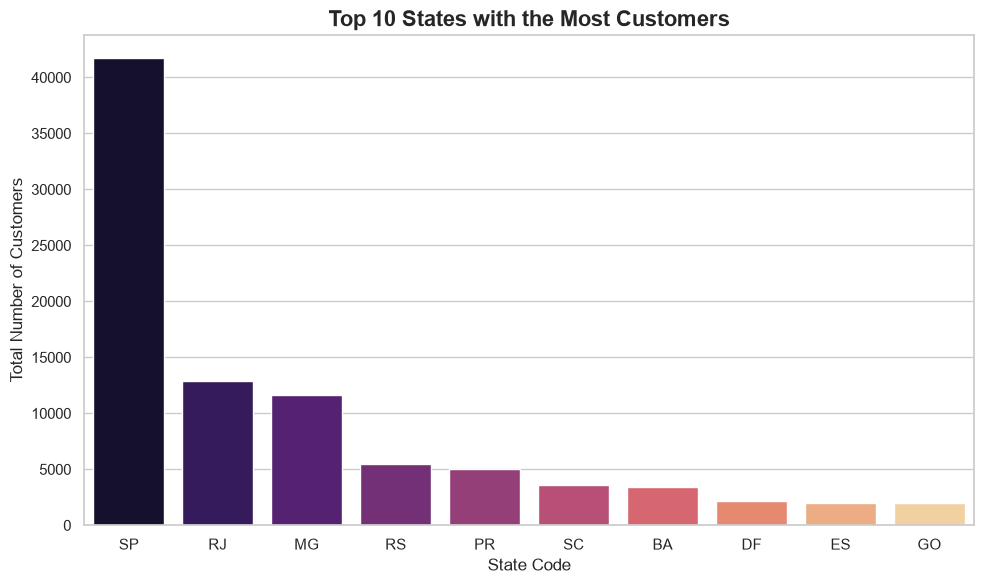

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
#Some adjustments for graphic size and background theme
plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid')
#Plot creation code (Vertical)
ax = sns.barplot(x='customer_state',
                 y='total_customers',
                 data=df_customers,
                 palette='magma',
                 hue='customer_state',
                 legend=False
)
#Title and axis names
plt.title('Top 10 States with the Most Customers', fontsize=16, fontweight='bold')
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Total Number of Customers', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
#Question: What are the top 10 product categories that generate the most revenue (sales)?
import pandas as pd
import sqlite3
#Connect Database
conn = sqlite3.connect('../database/olist.db')
query_revenue = """
SELECT 
    t.product_category_name_english AS category_name,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM 
    olist_order_items_dataset oi
JOIN 
    olist_products_dataset p ON oi.product_id = p.product_id
JOIN 
    product_category_name_translation t ON p.product_category_name = t.product_category_name
JOIN
    olist_orders_dataset o ON oi.order_id = o.order_id
WHERE 
    o.order_status = 'delivered'
GROUP BY 
    t.product_category_name_english
ORDER BY 
    total_revenue DESC
LIMIT 10;
"""

df_revenue = pd.read_sql_query(query_revenue,conn)
display(df_revenue)


,category_name,total_revenue
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61
5,furniture_decor,711927.69
6,housewares,615628.69
7,cool_stuff,610204.10
8,auto,578966.65
9,toys,471286.48


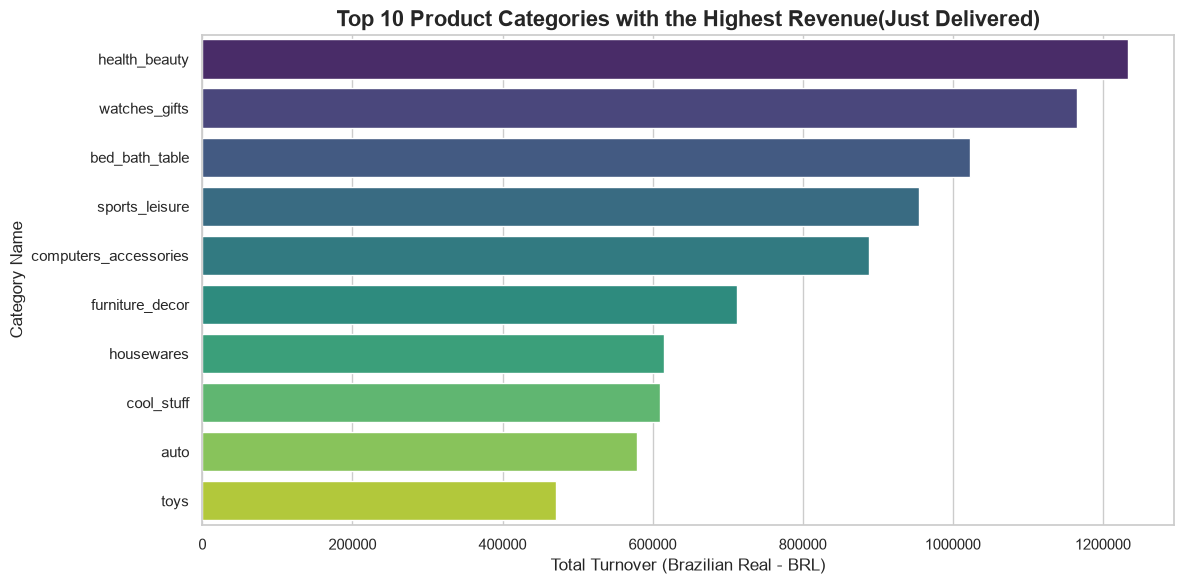

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
#Some adjustments for graphic size and background theme
plt.figure(figsize=(12,6))
sns.set_theme(style='whitegrid')
#Plot creation code
ax = sns.barplot(x='total_revenue',
                 y='category_name',
                 data=df_revenue,
                 hue='category_name',
                 palette='viridis',
                 legend=False
)
#Title and axis names
plt.title('Top 10 Product Categories with the Highest Revenue(Just Delivered)',fontsize=16,fontweight='bold')
plt.xlabel('Total Turnover (Brazilian Real - BRL)',fontsize=12)
plt.ylabel('Category Name',fontsize=12)

ax.ticklabel_format(style='plain',axis='x')

plt.tight_layout()
plt.show()

